# Data exploratory

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objs as go 
import plotly.offline as py 
import plotly.io as pio
# Use the external browser renderer to avoid nbformat-based mime rendering in some notebook kernels
pio.renderers.default = 'browser'
import math
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [29]:
print("\nTransaction features: \n")
df_txs_features = pd.read_csv("dataset/txs_features.csv")
df_txs_features

print("\nTransaction classes: \n")
df_txs_classes = pd.read_csv("dataset/txs_classes.csv")
df_txs_classes

print("\nTransaction-Transaction edgelist: \n")
df_txs_edgelist = pd.read_csv("dataset/txs_edgelist.csv")
df_txs_edgelist


Transaction features: 



,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_min,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.308900,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Transaction classes: 



,txId,class
0,3321,3
1,11108,3
2,51816,3
3,68869,2
4,89273,2
...,...,...
203764,158304003,3
203765,158303998,3
203766,158303966,3
203767,161526077,3



Transaction-Transaction edgelist: 



,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


In [30]:
df_txs_features.insert(loc=2, column='class', value=df_txs_classes['class'])
df_txs_features['class'].value_counts()

class
3    157205
2     42019
1      4545
Name: count, dtype: int64

<BarContainer object of 3 artists>

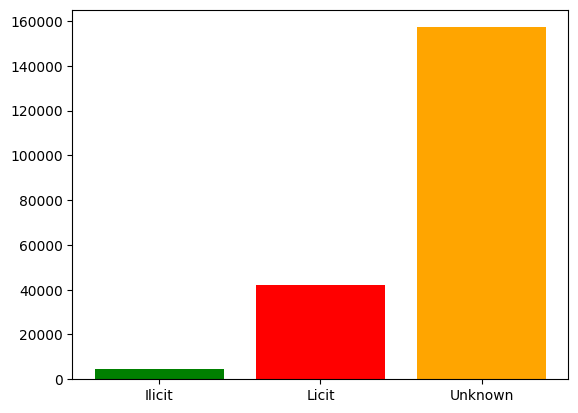

In [31]:
txs_by_class = df_txs_features.groupby('class').count()
plt.bar(['Ilicit', 'Licit', 'Unknown'], txs_by_class['txId'].values, color=['g', 'r', 'orange'] )

Text(0.5, 1.0, 'Number of transactions by time step')

C:\Users\alast\AppData\Local\Temp\ipykernel_2080\897365904.py:12: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Text(0.5, 0, 'Time step')

Text(0, 0.5, 'Number of transactions')

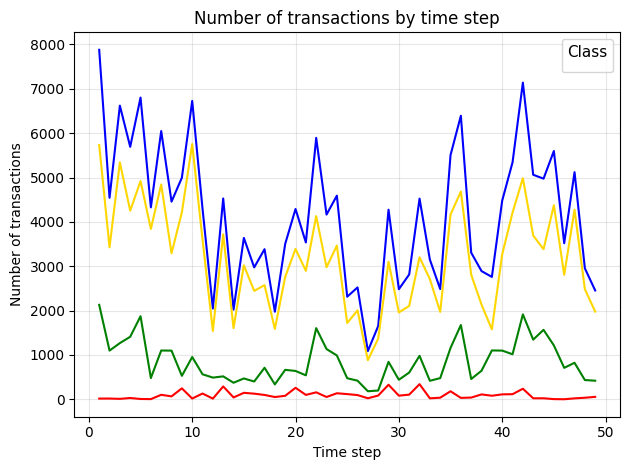

In [32]:
total_txs = df_txs_features.groupby('Time step').count()
illicit_txs = df_txs_features[df_txs_features['class']==1].groupby('Time step').count()
licit_txs = df_txs_features[df_txs_features['class']==2].groupby('Time step').count()
unknown_txs = df_txs_features[df_txs_features['class']==3].groupby('Time step').count()

plt.title('Number of transactions by time step')
plt.plot(total_txs['txId'], color='blue')
plt.plot(illicit_txs['txId'], color='red')
plt.plot(licit_txs['txId'], color='green')
plt.plot(unknown_txs['txId'], color='gold')

plt.legend(loc='upper right', frameon=True, fontsize=10, title='Class', title_fontsize=11)
plt.xlabel('Time step')
plt.ylabel('Number of transactions')
plt.grid(alpha=0.3)
plt.tight_layout()
     

In [33]:
grouped_class = df_txs_features[['Time step','class']].groupby(['Time step','class']).size().to_frame().reset_index()

timesteps = list(range(1,50))

fig = go.Figure(data = [
    go.Bar(name="Unknown (unlabelled)",x=timesteps,y=grouped_class[grouped_class['class'] == 3][0],marker = dict(color = 'orange', line = dict(color = 'orange',width=1))),
    go.Bar(name="Licit (non-fraud)",x=timesteps,y=grouped_class[grouped_class['class'] == 2][0],marker = dict(color = 'green', line = dict(color = 'green',width=1))),
    go.Bar(name="Illicit (fraud)",x=timesteps,y=grouped_class[grouped_class['class'] == 1][0],marker = dict(color = 'red', line = dict(color = 'red',width=1)))
])

fig.update_layout(barmode='stack')
     

In [34]:
unknown_count = grouped_class[grouped_class['class'] == 3]
illicit_count = grouped_class[grouped_class['class'] == 1]
licit_count = grouped_class[grouped_class['class'] == 2]

frames = [unknown_count, illicit_count, licit_count]
df_count_distribution = pd.concat(frames)
df_count_distribution.rename(columns={0: 'counts'}).sort_values('Time step')

,Time step,class,counts
2,1,3,5733
0,1,1,17
1,1,2,2130
5,2,3,3427
3,2,1,18
...,...,...,...
143,48,3,2483
141,48,1,36
144,49,1,56
146,49,3,1978


# Model training

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, TransformerConv

In [ ]:
# 1) Prepare node features X, labels y, and masks
#    - keep only numeric columns for X (drop identifiers + label)
drop_cols = {'txId','Time step','class'}
feat_cols = [c for c in df_txs_features.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df_txs_features[c])]
assert len(feat_cols) > 0, "No numeric feature columns found for X"

# Map txId -> node index
txid_to_idx = {tx_id: i for i, tx_id in enumerate(df_txs_features['txId'].values)}
num_nodes = len(txid_to_idx)

# X - Handle NaN values (do NOT fit scaler yet)
X_raw = df_txs_features[feat_cols].values
# Replace NaN with column median
X_filled = np.where(np.isnan(X_raw), np.nanmedian(X_raw, axis=0, keepdims=True), X_raw)

# y (binary for labeled nodes): map {Illicit=1, Licit=0}; Unknown=ignored (mask=False)
label_series = df_txs_features['class']  # 1=illicit, 2=licit, 3=unknown
is_labeled = label_series.isin([1,2]).values
# build numpy label array for convenience
y_np = np.full(num_nodes, -1, dtype=int)
y_np[label_series.values == 1] = 1
y_np[label_series.values == 2] = 0

# --- Use temporal split you provided: train = Time step < 35, test = Time step >= 35
# prefer df_txs_features_selected if present (you used it earlier for feature selection)
df_src = globals().get('df_txs_features_selected', df_txs_features)

train_txids = df_src.loc[(df_src['Time step'] < 35) & (df_src['class'] != 3), 'txId'].values
test_txids  = df_src.loc[(df_src['Time step'] >= 35) & (df_src['class'] != 3), 'txId'].values

# map txIds -> node indices (ignore any txId not present in mapping)
train_idx = [txid_to_idx[t] for t in train_txids if t in txid_to_idx]
test_idx  = [txid_to_idx[t] for t in test_txids  if t in txid_to_idx]

# optional: create a small validation split from the training timesteps (stratified if possible)
val_idx = []
if len(train_idx) > 0:
    try:
        train_idx, val_idx = train_test_split(
            train_idx,
            test_size=0.20,
            stratify=y_np[train_idx],
            random_state=42
        )
    except Exception:
        # fallback: non-stratified split if stratify fails (e.g., small classes)
        train_idx, val_idx = train_test_split(train_idx, test_size=0.20, random_state=42)

# Fit scaler ONLY on training nodes to avoid leakage
scaler = MinMaxScaler()
if len(train_idx) > 0:
    scaler.fit(X_filled[train_idx])
    X_normalized = scaler.transform(X_filled)
else:
    # fallback: fit on all if no train indices (shouldn't happen)
    X_normalized = scaler.fit_transform(X_filled)

X = torch.tensor(X_normalized, dtype=torch.float)

# Build edge_index (only keep edges where both endpoints exist)
edges_df = df_txs_edgelist[['txId1','txId2']].copy()
edges_df = edges_df[edges_df['txId1'].isin(txid_to_idx) & edges_df['txId2'].isin(txid_to_idx)]

src = edges_df['txId1'].map(txid_to_idx).values
dst = edges_df['txId2'].map(txid_to_idx).values
edge_index = torch.tensor([src, dst], dtype=torch.long)
# (optional) make undirected by adding reverse edges
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

# Build y tensor
y = torch.tensor(y_np, dtype=torch.long)

# Build masks for PyG (train/val/test) using the temporal indices
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

if len(train_idx) > 0:
    train_mask[torch.tensor(train_idx, dtype=torch.long)] = True
if len(val_idx) > 0:
    val_mask[torch.tensor(val_idx, dtype=torch.long)] = True
if len(test_idx) > 0:
    test_mask[torch.tensor(test_idx, dtype=torch.long)] = True

# 4) Build PyG Data object
from torch_geometric.data import Data

data = Data(x=X, edge_index=edge_index, y=y)
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

input_dim = data.num_features
hidden_dim = 64
num_classes = 2  # illicit vs licit



Training GCN Model
Class weights: Licit=0.000034, Illicit=0.000314
[Epoch 020] loss=0.5585  val_acc=0.6597  val_f1=0.3332
[Epoch 020] loss=0.5585  val_acc=0.6597  val_f1=0.3332
[Epoch 040] loss=0.4474  val_acc=0.7725  val_f1=0.4290
[Epoch 040] loss=0.4474  val_acc=0.7725  val_f1=0.4290
[Epoch 060] loss=0.4071  val_acc=0.8063  val_f1=0.4616
[Epoch 060] loss=0.4071  val_acc=0.8063  val_f1=0.4616
[Epoch 080] loss=0.3853  val_acc=0.8089  val_f1=0.4713
[Epoch 080] loss=0.3853  val_acc=0.8089  val_f1=0.4713
[Epoch 100] loss=0.3706  val_acc=0.8282  val_f1=0.4987
[Epoch 100] loss=0.3706  val_acc=0.8282  val_f1=0.4987
[Epoch 120] loss=0.3561  val_acc=0.8243  val_f1=0.4986
[Epoch 120] loss=0.3561  val_acc=0.8243  val_f1=0.4986
[Epoch 140] loss=0.3486  val_acc=0.8172  val_f1=0.4910
[Epoch 140] loss=0.3486  val_acc=0.8172  val_f1=0.4910
[Epoch 160] loss=0.3365  val_acc=0.8394  val_f1=0.5197
[Epoch 160] loss=0.3365  val_acc=0.8394  val_f1=0.5197
[Epoch 180] loss=0.3278  val_acc=0.8537  val_f1=0.54

,txId,Time step,class,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,...,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,gcn_pred,gcn_pred_p_illicit,gat_pred,gat_pred_p_illicit,transformer_pred,transformer_pred_p_illicit
0,3321,1,3,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,0.367074,0.266986,0.266986,0.533972,0,3.758257e-02,0,0.007733,0,0.000029
1,11108,1,3,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,5.025584,2.805889,2.805889,5.611778,1,6.468956e-01,0,0.208850,1,0.908433
2,51816,1,3,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,0.228518,0.228254,0.228254,0.456508,1,5.448407e-01,0,0.214236,0,0.056561
3,68869,1,2,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,...,8.079800,4.654400,4.654400,9.308800,0,4.446060e-04,0,0.000112,0,0.001891
4,89273,1,2,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,...,41.264036,0.065016,0.000441,852.164680,0,4.243327e-36,0,0.000172,0,0.000024


<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(220.72222222222223, 0.5, 'True')

Text(0.5, 1.0, 'GCN: Confusion Matrix')

<Axes: >

...

Text(0.5, 1.0, 'GAT: Confusion Matrix')

<Axes: >

Text(0.5, 36.72222222222221, 'Predicted')

Text(1314.8398692810458, 0.5, 'True')

Text(0.5, 1.0, 'Graph Transformer: Confusion Matrix')

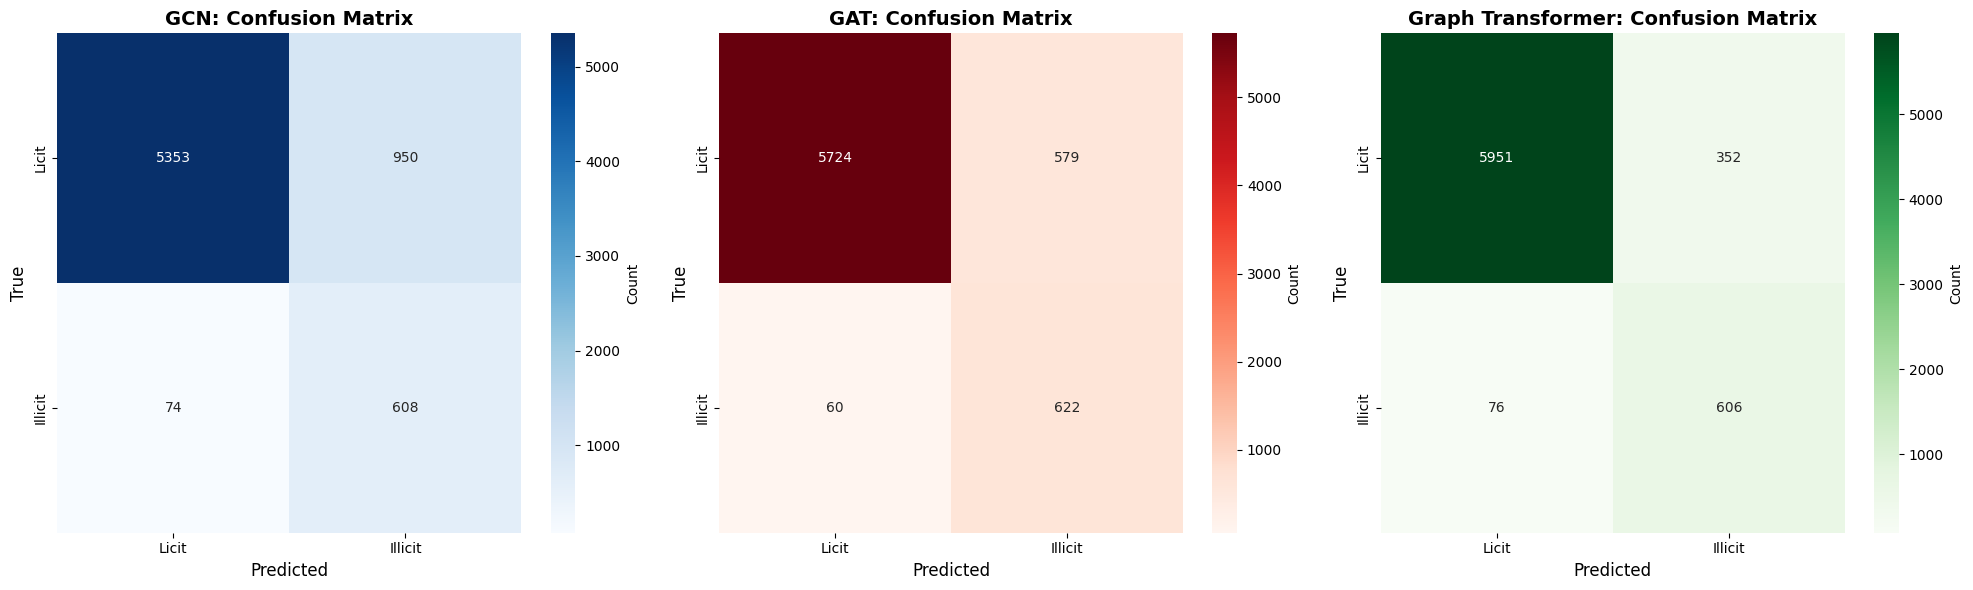


=== GCN Confusion Matrix ===
True Negatives (Licit predicted as Licit): 5353
False Positives (Licit predicted as Illicit): 950
False Negatives (Illicit predicted as Licit): 74
True Positives (Illicit predicted as Illicit): 608

=== GAT Confusion Matrix ===
True Negatives (Licit predicted as Licit): 5724
False Positives (Licit predicted as Illicit): 579
False Negatives (Illicit predicted as Licit): 60
True Positives (Illicit predicted as Illicit): 622

=== Graph Transformer Confusion Matrix ===
True Negatives (Licit predicted as Licit): 5951
False Positives (Licit predicted as Illicit): 352
False Negatives (Illicit predicted as Licit): 76
True Positives (Illicit predicted as Illicit): 606


In [37]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrices
@torch.no_grad()
def get_confusion_matrix(model, data, mask):
    model.eval()
    logits = model(data.x, data.edge_index)
    preds = logits[mask].argmax(dim=-1).cpu().numpy()
    true = data.y[mask].cpu().numpy()
    return confusion_matrix(true, preds)

gcn_cm = get_confusion_matrix(gcn, data, data.test_mask)
gat_cm = get_confusion_matrix(gat, data, data.test_mask)
transformer_cm = get_confusion_matrix(transformer, data, data.test_mask)

# Plot confusion matrices
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# GCN Confusion Matrix
sns.heatmap(gcn_cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
ax1.set_title('GCN: Confusion Matrix', fontsize=14, fontweight='bold')

# GAT Confusion Matrix
sns.heatmap(gat_cm, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax2.set_xlabel('Predicted', fontsize=12)
ax2.set_ylabel('True', fontsize=12)
ax2.set_title('GAT: Confusion Matrix', fontsize=14, fontweight='bold')

# Transformer Confusion Matrix
sns.heatmap(transformer_cm, annot=True, fmt='d', cmap='Greens', ax=ax3,
            xticklabels=['Licit', 'Illicit'], 
            yticklabels=['Licit', 'Illicit'],
            cbar_kws={'label': 'Count'})
ax3.set_xlabel('Predicted', fontsize=12)
ax3.set_ylabel('True', fontsize=12)
ax3.set_title('Graph Transformer: Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print additional metrics
print("\n=== GCN Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {gcn_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {gcn_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {gcn_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {gcn_cm[1,1]}")

print("\n=== GAT Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {gat_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {gat_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {gat_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {gat_cm[1,1]}")

print("\n=== Graph Transformer Confusion Matrix ===")
print(f"True Negatives (Licit predicted as Licit): {transformer_cm[0,0]}")
print(f"False Positives (Licit predicted as Illicit): {transformer_cm[0,1]}")
print(f"False Negatives (Illicit predicted as Licit): {transformer_cm[1,0]}")
print(f"True Positives (Illicit predicted as Illicit): {transformer_cm[1,1]}")

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Loss')

Text(0.5, 1.0, 'GCN: Training Loss vs Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Loss')

Text(0.5, 1.0, 'GAT: Training Loss vs Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Loss')

Text(0.5, 1.0, 'Graph Transformer: Training Loss vs Epoch')

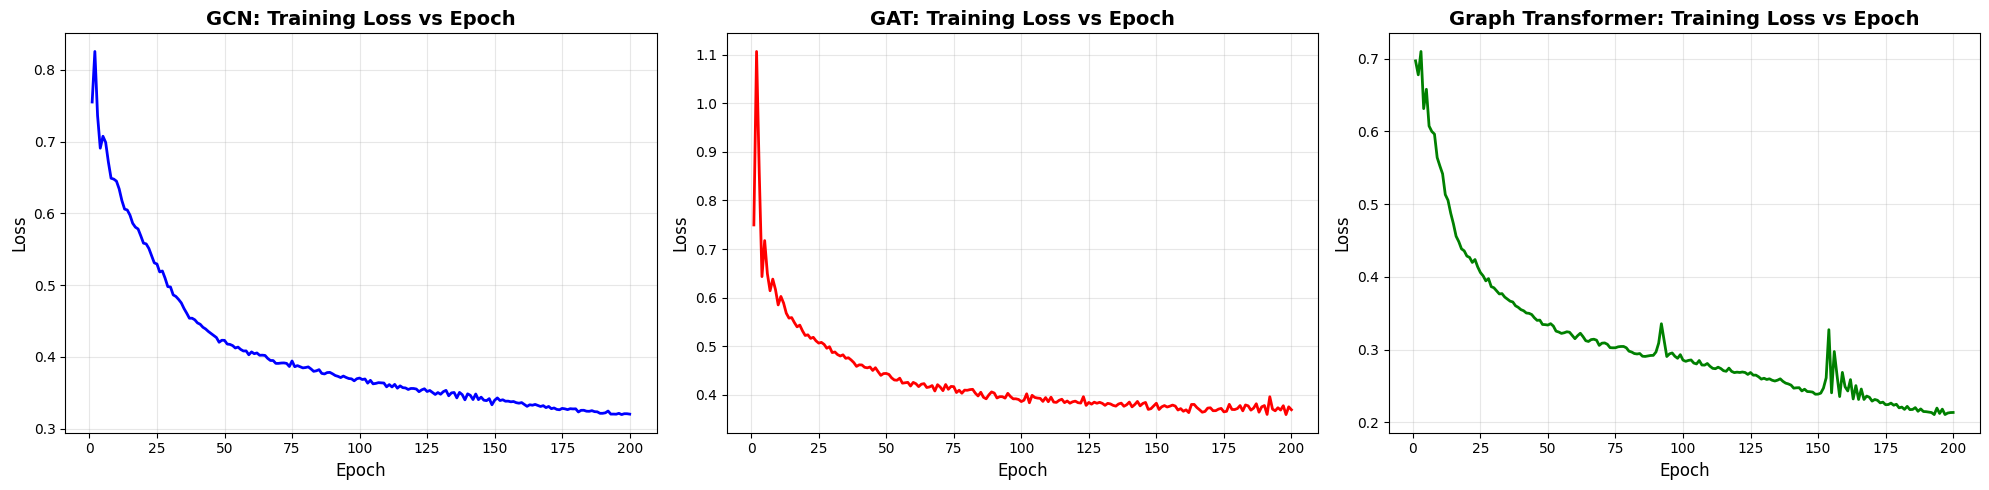

In [38]:
# Plot Epoch vs Loss graphs
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# GCN Loss
ax1.plot(range(1, len(gcn_loss_history) + 1), gcn_loss_history, 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('GCN: Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# GAT Loss
ax2.plot(range(1, len(gat_loss_history) + 1), gat_loss_history, 'r-', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('GAT: Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Transformer Loss
ax3.plot(range(1, len(transformer_loss_history) + 1), transformer_loss_history, 'g-', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Loss', fontsize=12)
ax3.set_title('Graph Transformer: Training Loss vs Epoch', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()